# 실험 2: Diffusion 오버샘플링, DDPM 300스텝

In [ ]:
import os
import subprocess

GPU_ID = None 


def pick_free_gpu():
    out = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=index,memory.used,utilization.gpu", "--format=csv,noheader,nounits"]
    ).decode()
    rows = [tuple(int(v) for v in line.split(",")) for line in out.strip().splitlines()]
    for idx, mem, util in rows:
        print(f"  GPU {idx}: memory {mem} MiB, util {util}%")
    return str(min(rows, key=lambda r: (r[1], r[2]))[0])


if GPU_ID is None:
    GPU_ID = pick_free_gpu()
os.environ["CUDA_VISIBLE_DEVICES"] = GPU_ID
print("사용 GPU:", GPU_ID)
RUN_SEEDS = list(range(10))  # seed 0~9 전부

  GPU 0: memory 12945 MiB, util 100%
  GPU 1: memory 3 MiB, util 0%
  GPU 2: memory 3 MiB, util 0%
사용 GPU: 1


## 0. 라이브러리 & 공통 유틸 / 모델 정의

In [2]:
%load_ext autoreload
%autoreload 2

In [ ]:
import sys
if ".." not in sys.path:
    sys.path.insert(0, "..")

import os
import time
from collections import Counter

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
from torchvision import transforms as T
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid

from models import Unet, Classifier
from utils import (
    set_seed, DEVICE, SEEDS, EMA,
    evaluate_classifier, metrics_to_rows, append_result_rows,
)
from diffusion import GaussianDiffusion
from data import (
    build_imbalanced_split, CachedDataset, CachedSubset, BalancedDataset,
    generate_balanced_fake, draw_from_pool,
)

SEEDS = [s for s in SEEDS if s in RUN_SEEDS]

print("device:", DEVICE)
print("모델/유틸/데이터 모듈 로드 완료 (models.py, utils.py, diffusion.py, data.py)")


site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda
모델/유틸/데이터 모듈 로드 완료 (models.py, utils.py, diffusion.py, data.py)


## 1. 데이터 생성: 불균형 데이터셋

In [4]:
image_size = 64
channels = 3
batch_size = 40
num_classes = 3

data_root = os.environ.get("DATA_ROOT", "../../data/256")

RESULTS_CSV = "exp2_oversampling_step_300.csv"
if os.path.exists(RESULTS_CSV):
    os.remove(RESULTS_CSV)

CLASS_NAMES = ["Normal", "Underfill_50FR", "Underfill_Fan"]  # ImageFolder는 폴더명 알파벳순으로 라벨을 매김 (Normal=0, Underfill_50FR=1, Underfill_Fan=2)

train_counts = {0: 800, 1: 80, 2: 80}
test_counts = {0: 100, 1: 100, 2: 100}

transform = T.Compose([
    T.Resize((image_size, image_size)),
    T.ToTensor(),
    T.Lambda(lambda t: (t * 2) - 1),  # [0,1] -> [-1,1]
])

full_dataset = ImageFolder(root=data_root, transform=transform)
assert full_dataset.classes == CLASS_NAMES, full_dataset.classes

full_cached = CachedDataset(full_dataset)


def set_split(seed):
    global train_indices, test_indices, train_dataset, test_dataset
    global train_loader, test_loader, train_labels, test_labels
    train_indices, test_indices = build_imbalanced_split(full_dataset, train_counts, test_counts, seed=seed)

    train_dataset = CachedSubset(full_cached, train_indices)
    test_dataset = CachedSubset(full_cached, test_indices)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True,
                               pin_memory=(DEVICE == "cuda"))
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                              pin_memory=(DEVICE == "cuda"))

    train_labels = [full_dataset.samples[i][1] for i in train_indices]
    test_labels = [full_dataset.samples[i][1] for i in test_indices]


set_split(0)  # 미리보기/학습량 기준(BASELINE_STEPS) 계산용 초기 분할
print("SEEDS:", SEEDS)
print("Train label distribution:", Counter(train_labels))
print("Test  label distribution:", Counter(test_labels))


SEEDS: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Train label distribution: Counter({0: 800, 1: 80, 2: 80})
Test  label distribution: Counter({0: 100, 1: 100, 2: 100})


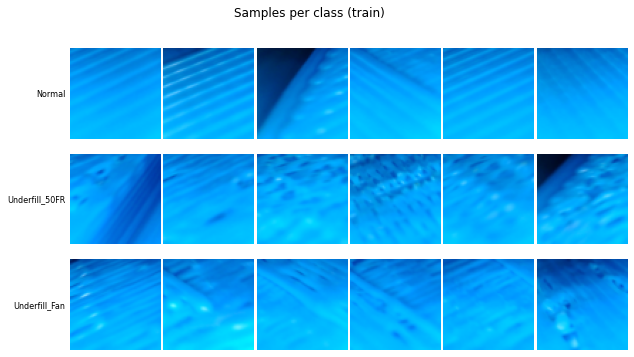

In [5]:
def denorm(x):
    return (x + 1) / 2

W, L, R = 9, 0.13, 0.99
cell = W * (R - L) / 6
H = num_classes * cell + 0.6
fig, axes = plt.subplots(num_classes, 6, figsize=(W, H))
for cls in range(num_classes):
    idxs = [i for i, y in enumerate(train_labels) if y == cls][:6]
    for j, idx in enumerate(idxs):
        img, _ = train_dataset[idx]
        axes[cls, j].imshow(denorm(img).permute(1, 2, 0).numpy())
        axes[cls, j].axis("off")
    axes[cls, 0].text(-0.05, 0.5, CLASS_NAMES[cls], transform=axes[cls, 0].transAxes,
                      ha="right", va="center", fontsize=8)
plt.suptitle("Samples per class (train)")
plt.subplots_adjust(left=L, right=R, bottom=0.05 / H, top=1 - 0.55 / H, wspace=0.03, hspace=0.03)
plt.show()

## 2. Diffusion / 평가 공통 유틸

In [ ]:
timesteps = 300
ddpm = GaussianDiffusion(timesteps=timesteps, image_size=image_size, channels=channels)

print("diffusion/평가 유틸 정의 완료")

CLASSIFIER_EPOCHS_REF = 50
BASELINE_STEPS = len(train_loader) * CLASSIFIER_EPOCHS_REF
print(f"분류기 학습 기준 step 수 (BASELINE_STEPS) = {len(train_loader)} batches/epoch "
      f"x {CLASSIFIER_EPOCHS_REF} epochs = {BASELINE_STEPS}")


DIFFUSION_EPOCHS_REF = 700
EMA_DECAY = 0.999


def train_classifier_for_steps(loader, total_steps, seed, tag="Classifier"):
    set_seed(seed)
    device = DEVICE

    classifier = Classifier(num_classes=num_classes, img_channels=channels).to(device)
    opt_c = torch.optim.Adam(classifier.parameters(), lr=1e-3)
    cls_loss_fn = nn.CrossEntropyLoss()

    classifier.train()
    data_iter = iter(loader)
    losses = []
    pbar = tqdm(range(total_steps), desc=f"[{tag} seed{seed}] steps", leave=False)
    t0 = time.time()

    for step in pbar:
        try:
            x, y = next(data_iter)
        except StopIteration:
            data_iter = iter(loader)
            x, y = next(data_iter)

        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

        logits = classifier(x)
        loss = cls_loss_fn(logits, y)

        opt_c.zero_grad()
        loss.backward()
        opt_c.step()

        losses.append(loss.item())
        pbar.set_postfix(cls=f"{loss.item():.4f}")

        if (step + 1) % max(1, total_steps // 10) == 0 or step == total_steps - 1:
            print(f"[{tag} seed{seed}] step {step+1}/{total_steps} Cls={np.mean(losses[-50:]):.4f} "
                  f"elapsed={time.time()-t0:.1f}s")

    return classifier


## 실험 2: Diffusion 오버샘플링 (DDPM 300스텝 fake 풀)

In [ ]:
def train_diffusion(seed, epochs=None):
    epochs = epochs or DIFFUSION_EPOCHS_REF
    set_seed(seed)
    device = DEVICE

    diffusion = Unet(dim=32, channels=channels, num_classes=num_classes).to(device)
    opt_g = torch.optim.Adam(diffusion.parameters(), lr=2e-4)
    diffusion_loss_fn = nn.MSELoss()
    ema = EMA(diffusion, decay=EMA_DECAY)
    t0 = time.time()

    pbar = tqdm(range(epochs), desc=f"[Diffusion seed{seed}]")
    for epoch in pbar:
        diffusion.train()
        epoch_losses = []
        for x, y in train_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            t = torch.randint(0, timesteps, (x.size(0),), device=device)
            noise = torch.randn_like(x)
            x_noisy = ddpm.q_sample(x, t, noise)

            pred_noise = diffusion(x_noisy, t, y)
            loss = diffusion_loss_fn(pred_noise, noise)

            opt_g.zero_grad()
            loss.backward()
            opt_g.step()
            ema.update(diffusion)

            epoch_losses.append(loss.item())

        pbar.set_postfix(diff=f"{np.mean(epoch_losses):.4f}")

        if (epoch + 1) % 100 == 0 or epoch == epochs - 1:
            tqdm.write(f"[Diffusion seed{seed}] Epoch {epoch+1}/{epochs} Diff={np.mean(epoch_losses):.4f} "
                  f"elapsed={time.time()-t0:.1f}s")

    return diffusion, ema


def train_classifier_on(dataset, seed, total_steps=None):
    total_steps = total_steps or BASELINE_STEPS
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True,
                         pin_memory=(DEVICE == "cuda"))
    return train_classifier_for_steps(loader, total_steps, seed, tag="Classifier")


DIFFUSION_PATH = "exp2_diffusion_seed{seed}.pt"
DIFFUSION_EMA_PATH = "exp2_diffusion_ema_seed{seed}.pt"


def load_or_train_diffusion(seed):
    path, ema_path = DIFFUSION_PATH.format(seed=seed), DIFFUSION_EMA_PATH.format(seed=seed)
    if os.path.exists(path) and os.path.exists(ema_path):
        diffusion = Unet(dim=32, channels=channels, num_classes=num_classes).to(DEVICE)
        diffusion.load_state_dict(torch.load(path, map_location=DEVICE))
        ema = EMA(diffusion, decay=EMA_DECAY)
        ema.model.load_state_dict(torch.load(ema_path, map_location=DEVICE))
        print(f"[Diffusion seed{seed}] 학습 건너뜀: {path}, {ema_path} 로드")
        return diffusion, ema, False
    diffusion, ema = train_diffusion(seed)
    return diffusion, ema, True


In [ ]:
POOL_PER_CLASS = 800 - 80
POOL_GEN_BATCH = 360  # 한 번의 샘플링 호출로 생성할 장 수 (클래스당 2번 호출)
POOL_PATH = "exp2_fake_pool_seed{seed}.pt"


def load_or_build_pool(seed, gen_model, minority_classes=(1, 2)):
    path = POOL_PATH.format(seed=seed)
    if os.path.exists(path):
        pool = torch.load(path, map_location="cpu")
        print(f"[Pool seed{seed}] 생성 건너뜀: {path} 로드")
    else:
        set_seed(seed)
        t0 = time.time()
        pool = generate_balanced_fake(ddpm, gen_model, DEVICE, target_per_class=POOL_PER_CLASS, minority_classes=minority_classes,
                                      batch_size=POOL_GEN_BATCH)
        torch.save(pool, path)
        print(f"[Pool seed{seed}] 클래스당 {POOL_PER_CLASS}장 생성 완료: {time.time()-t0:.1f}초 → {path}")
    return {cls: x.to(DEVICE) for cls, x in pool.items()}


def train_classifier_pool(seed, pool, total_steps=None):
    total_steps = total_steps or BASELINE_STEPS
    set_seed(seed)
    device = DEVICE

    classifier = Classifier(num_classes=num_classes, img_channels=channels).to(device)
    opt_c = torch.optim.Adam(classifier.parameters(), lr=1e-3)
    cls_loss_fn = nn.CrossEntropyLoss()

    classifier.train()
    data_iter = iter(train_loader)
    losses = []
    t0 = time.time()
    pbar = tqdm(range(total_steps), desc=f"[Classifier-pool seed{seed}]")

    for step in pbar:
        try:
            x, y = next(data_iter)
        except StopIteration:
            data_iter = iter(train_loader)
            x, y = next(data_iter)
        x, y = x.to(device), y.to(device)

        x_fake, y_fake = draw_from_pool(pool, y, device)
        if x_fake is not None:
            x = torch.cat([x, x_fake], dim=0)
            y = torch.cat([y, y_fake], dim=0)

        loss = cls_loss_fn(classifier(x), y)
        opt_c.zero_grad()
        loss.backward()
        opt_c.step()

        losses.append(loss.item())
        if (step + 1) % 50 == 0:
            pbar.set_postfix(cls=f"{np.mean(losses[-50:]):.4f}")
        if (step + 1) % max(1, total_steps // 10) == 0 or step == total_steps - 1:
            tqdm.write(f"[Classifier-pool seed{seed}] step {step+1}/{total_steps} "
                       f"Cls={np.mean(losses[-50:]):.4f} elapsed={time.time()-t0:.1f}s")

    return classifier


onthefly_rows = []
onthefly_models = {}  # 미리보기용 EMA 모델

for seed in SEEDS:
    set_split(seed)  # seed마다 train/test 분할을 새로 뽑는다 (학습 전에 반드시 먼저)
    print(f"\n===== Diffusion oversampling (pool DDPM{timesteps}) | Seed {seed} =====")
    t0 = time.time()
    diffusion, ema, trained = load_or_train_diffusion(seed)
    if trained:
        torch.save(diffusion.state_dict(), DIFFUSION_PATH.format(seed=seed))
        torch.save(ema.model.state_dict(), DIFFUSION_EMA_PATH.format(seed=seed))

    onthefly_models[seed] = ema.model
    pool = load_or_build_pool(seed, ema.model)
    classifier_otf = train_classifier_pool(seed, pool)
    print(f"[Exp2 seed{seed}] 총 소요 시간: {time.time()-t0:.1f}초")

    metrics = evaluate_classifier(classifier_otf, test_loader, DEVICE, num_classes, CLASS_NAMES)
    rows = metrics_to_rows(metrics, seed, "exp2_oversampling_step_300")
    onthefly_rows.extend(rows)
    append_result_rows(rows, RESULTS_CSV)

df_onthefly = pd.DataFrame(onthefly_rows)
df_onthefly

In [ ]:
seed_to_show = SEEDS[0]
diffusion = onthefly_models[seed_to_show]
with torch.no_grad():
    y_vis = torch.tensor([0] * 6 + [1] * 6 + [2] * 6, device=DEVICE)
    x_vis = ddpm.sample_ddpm(diffusion, y_vis, DEVICE)
grid = make_grid(denorm(x_vis).clamp(0, 1).cpu(), nrow=6)
plt.figure(figsize=(8, 4.5))
plt.imshow(grid.permute(1, 2, 0), cmap="gray")
plt.axis("off")
plt.title(f"Exp 2: samples generated by DDPM{timesteps} (EMA) - class 0 / class 1 / class 2 (top to bottom)")
plt.show()